In [1]:
import biolqm
import ginsim
from colomoto.minibn import BooleanNetwork
from colomoto_jupyter import tabulate
import pandas as pd # for displaying list of fixpoints

This notebook has been executed using the docker image `colomoto/colomoto-docker:2019-12-19`

## Create Model

In [2]:
F = BooleanNetwork()

In [3]:
a, b, c ,d , e, f = F.vars("a", "b", "c","d", "e", "f")


In [4]:
F[a] = a
F[b] = ~d&(a|c)
F[c] = b
F[d] = f
F[e] = ~d&c
F[f] = ~d & e

In [5]:
F

a <- a
b <- !d&(a|c)
c <- b
d <- f
e <- !d&c
f <- !d&e

In [6]:
lqm = F.to_biolqm()

In [7]:
lrg = biolqm.to_ginsim(lqm)

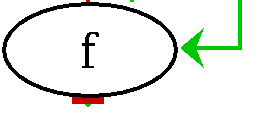

In [144]:
ginsim.show(lrg)

#### Perform simulations starting from states 1, 4, 21 and 33.

In [8]:
#state 1
trace1 = biolqm.trace(lqm, "-u synchronous -i 100000 -m 50")
pd.DataFrame( [s for s in trace1] )

,a,b,c,d,e,f
0,1,0,0,0,0,0
1,1,1,0,0,0,0
2,1,1,1,0,0,0
3,1,1,1,0,1,0
4,1,1,1,0,1,1
5,1,1,1,1,1,1
6,1,0,1,1,0,0
7,1,0,0,0,0,0


In [9]:
#state 4
trace2 = biolqm.trace(lqm, "-u synchronous -i 001000 -m 50")
pd.DataFrame( [s for s in trace2] )

,a,b,c,d,e,f
0,0,0,1,0,0,0
1,0,1,0,0,1,0
2,0,0,1,0,0,1
3,0,1,0,1,1,0
4,0,0,1,0,0,0


In [10]:
#state 21
trace3 = biolqm.trace(lqm, "-u synchronous -i 101010 -m 50")
pd.DataFrame( [s for s in trace3] )

,a,b,c,d,e,f
0,1,0,1,0,1,0
1,1,1,0,0,1,1
2,1,1,1,1,0,1
3,1,0,1,1,0,0
4,1,0,0,0,0,0
5,1,1,0,0,0,0
6,1,1,1,0,0,0
7,1,1,1,0,1,0
8,1,1,1,0,1,1
9,1,1,1,1,1,1


In [12]:
#state 33
trace4 = biolqm.trace(lqm, "-u synchronous -i 100001 -m 50")
pd.DataFrame( [s for s in trace4] )

,a,b,c,d,e,f
0,1,0,0,0,0,1
1,1,1,0,1,0,0
2,1,0,1,0,0,0
3,1,1,0,0,1,0
4,1,1,1,0,0,1
5,1,1,1,1,1,0
6,1,0,1,0,0,0


## Attractors & Fixpoints

#### Attractors

In [177]:
m = ginsim.to_pint(lrg)

In [190]:
m.initial_state.update(a=1, b=0, c=1, d=0, e=0, f=0)

In [191]:
m.initial_state

{'a': 1, 'b': 0, 'c': 1, 'd': 0, 'e': 0, 'f': 0}

In [192]:
attractors = m.reachable_attractors()

In [193]:
attractors

[{'type': 'cyclic',
  'size': 31,
  'sample': {'a': 1, 'b': 0, 'c': 1, 'd': 0, 'e': 0, 'f': 0}}]

# computing graph layout...


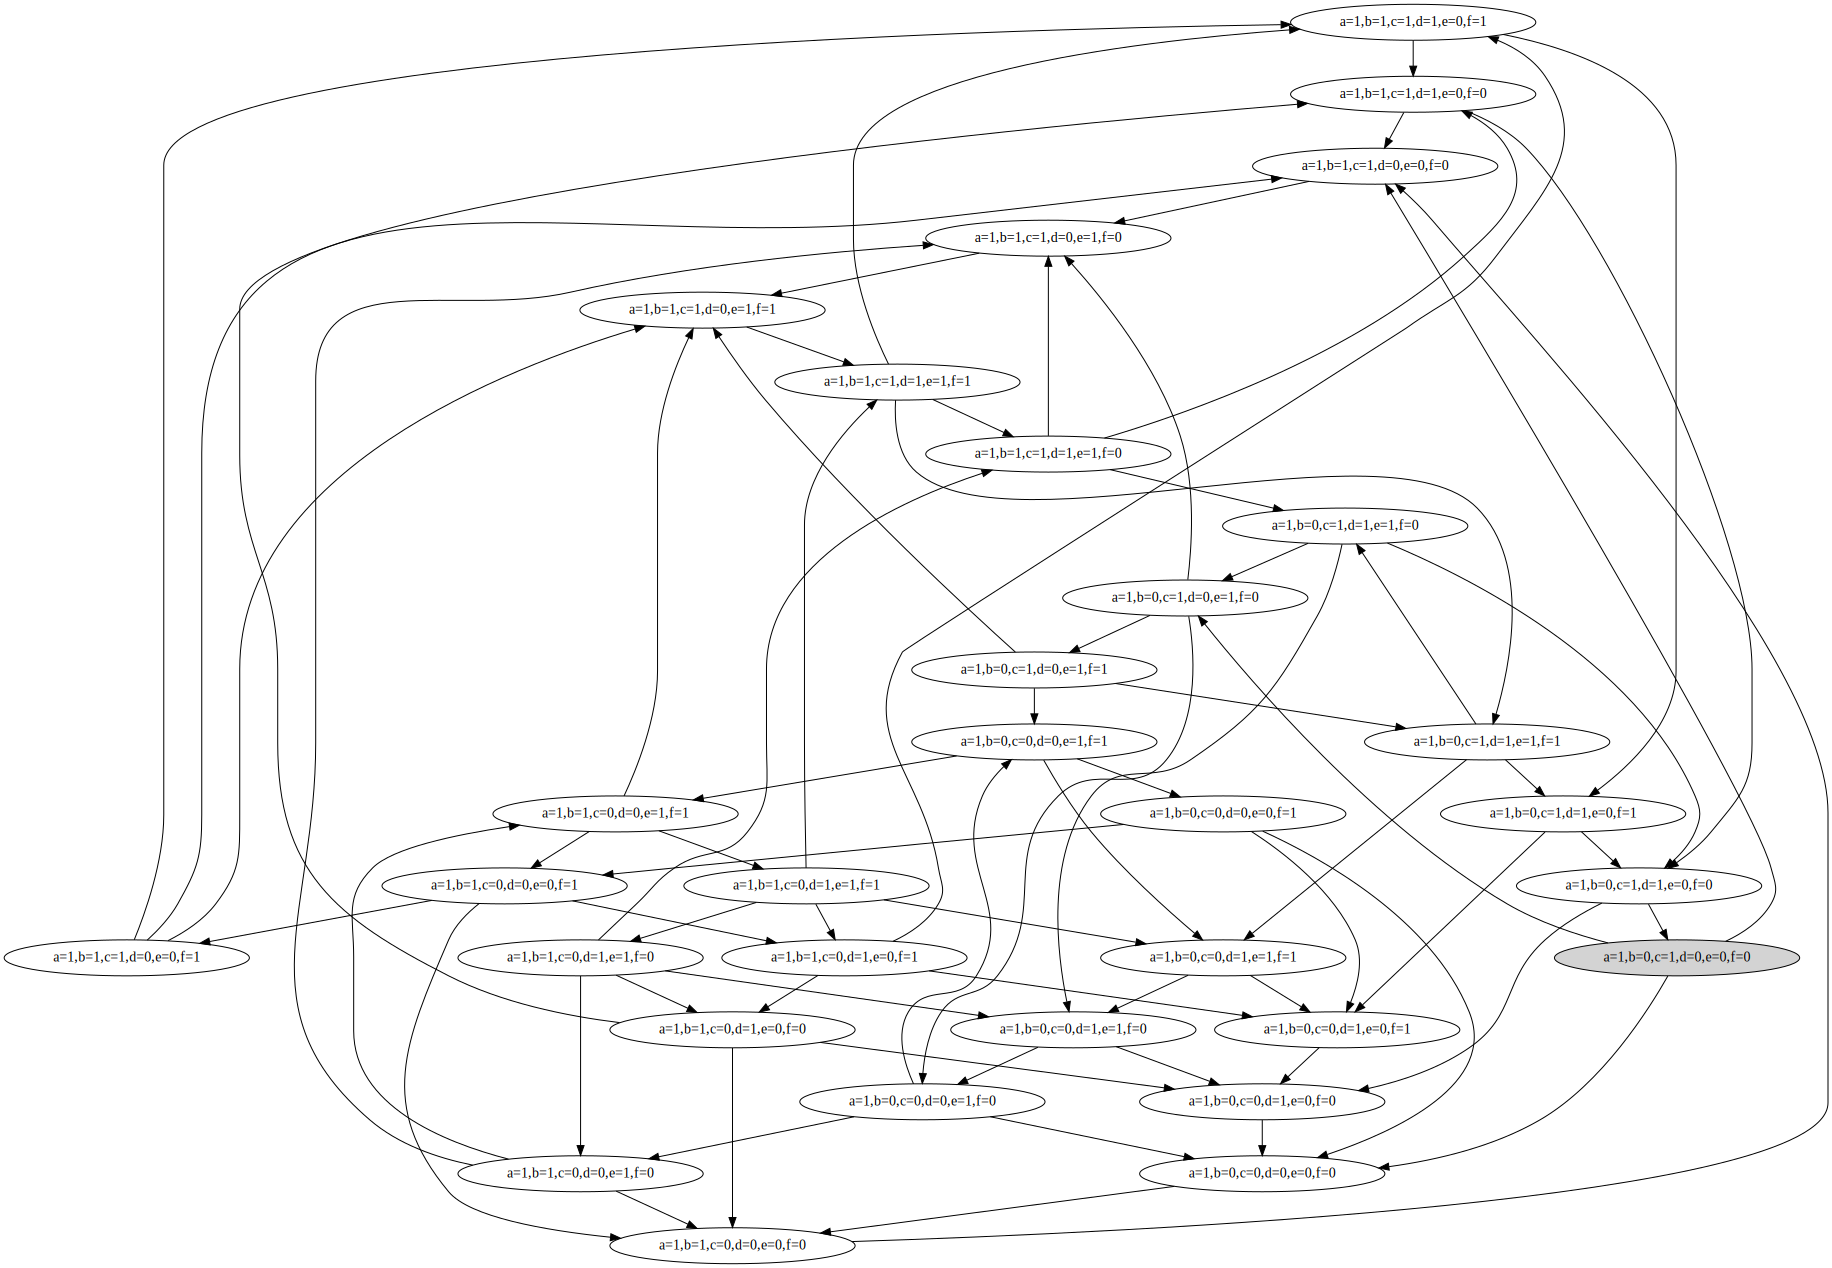

In [196]:
m.having(attractors[0]["sample"]).reachable_stategraph()

#### Fixpoints

In [14]:
fps = biolqm.fixpoints(lqm)
print(len(fps), "fixpoints")
pd.DataFrame(fps)

1 fixpoints


,a,b,c,d,e,f
0,0,0,0,0,0,0


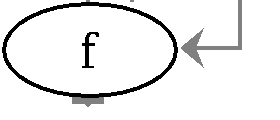

In [65]:
ginsim.show(lrg, fps[0])

In [15]:
#state 6
trace5 = biolqm.trace(lqm, "-u synchronous -i 011000 -m 50")
pd.DataFrame( [s for s in trace5] )

,a,b,c,d,e,f
0,0,1,1,0,0,0
1,0,1,1,0,1,0
2,0,1,1,0,1,1
3,0,1,1,1,1,1
4,0,0,1,1,0,0
5,0,0,0,0,0,0


In [16]:
#state 22
trace5 = biolqm.trace(lqm, "-u synchronous -i 011010 -m 50")
pd.DataFrame( [s for s in trace5] )

,a,b,c,d,e,f
0,0,1,1,0,1,0
1,0,1,1,0,1,1
2,0,1,1,1,1,1
3,0,0,1,1,0,0
4,0,0,0,0,0,0


In [30]:
#state 20
trace5 = biolqm.trace(lqm, "-u synchronous -i 001010 -m 50")
pd.DataFrame( [s for s in trace5] )

,a,b,c,d,e,f
0,0,0,1,0,1,0
1,0,1,0,0,1,1
2,0,0,1,1,0,1
3,0,0,0,1,0,0
4,0,0,0,0,0,0
